# Revenue-Optimal Dynamic Pricing using Reinforcement Learning  
#### Policy Learning in a Competitive and Seasonal Synthetic Market

--- 

A company has recently launched a new product, but early performance has been disappointing. Sales volumes remain low, margins are unstable, and there is no historical data available on how customers respond to price changes. At the same time, the market is highly competitive, with competitors adjusting their prices frequently in response to observed behavior.

A new Pricing Manager is hired to address the situation. Given the lack of data, the problem cannot be solved immediately with advanced machine learning techniques. Instead, the manager proposes a structured, phased approach that allows the company to gradually learn about demand, competition, and optimal pricing strategies while maintaining business performance.

The project progresses through the following phases:

- Phase 0: data simulation  
- Phase 1: structural demand and elasticity validation  
- Phase 2: myopic revenue optimization  
- Phase 3: adaptive pricing via contextual bandits

Dynamic pricing with reinforcement learning has broad applicability across industries where prices can be adjusted frequently and demand is uncertain or reactive. Examples include e-commerce and retail, airlines and hospitality, ride-hailing platforms, financial services, and digital marketplaces.


### Phase 0: Data simulation

During the initial quarter, before any reliable data is available, the manager implements a **mean-reverting pricing policy**. Prices are anchored around a reference level informed by prior market knowledge, while allowing controlled deviations based on observable signals such as competitor pricing and realized demand. 

By the end of this phase, the system produces a consistent and sufficiently rich dataset, including prices, demand, competitor behavior, and revenue. This dataset serves as the foundation for all subsequent phases, where more advanced modeling and optimization techniques will be introduced.

In [8]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import exploration_policy, simulate, MarketPriors

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()


In [9]:
priors = MarketPriors()
df_first_qt = simulate(90, exploration_policy, priors)

print(df_first_qt.shape)
df_first_qt.tail()

(90, 7)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue
85,2025-03-27,100.000000,133.046471,2.100213e-05,-0.051623,16.235496,449.419827
86,2025-03-28,104.916917,144.938703,7.726252e-06,-0.049898,16.719392,550.983552
87,2025-03-29,160.000000,160.000000,2.718770e-06,-0.177625,3.754896,175.489575
88,2025-03-30,130.501164,160.000000,9.151115e-07,-0.071697,9.134093,443.964167
89,2025-03-31,144.589350,127.327932,2.946277e-07,0.064606,4.089074,145.892151


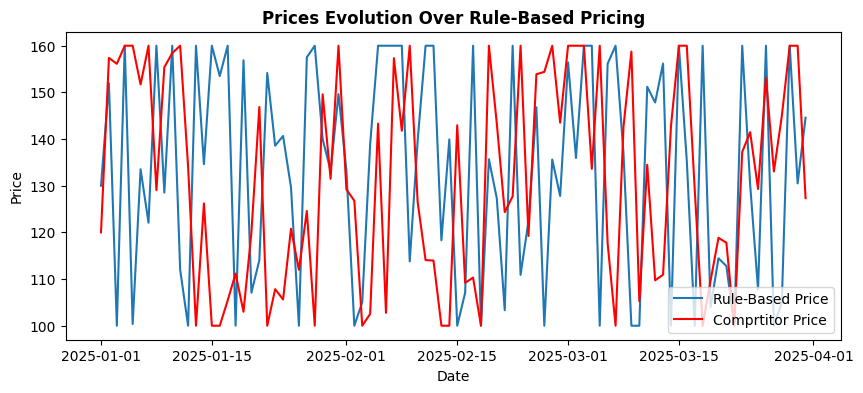

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["price_agent"], label="Rule-Based Price")
plt.plot(df_first_qt["date"], df_first_qt["price_competitor"], label="Comprtitor Price", color="red")

plt.legend(loc="lower right")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.title("Prices Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

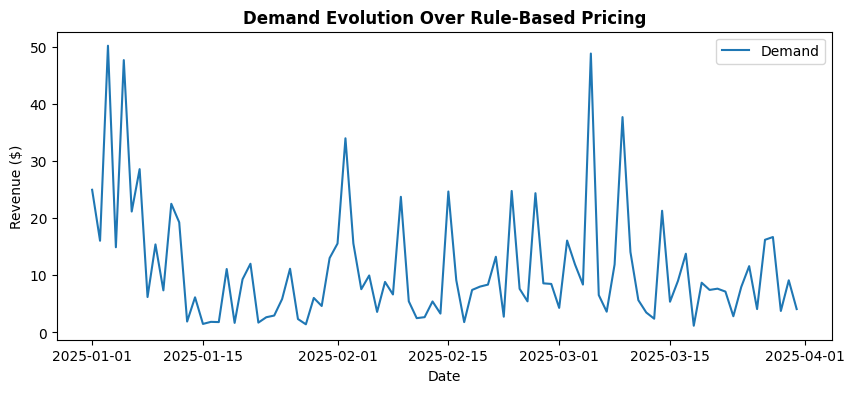

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["realized_demand"], label="Demand")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.title("Demand Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

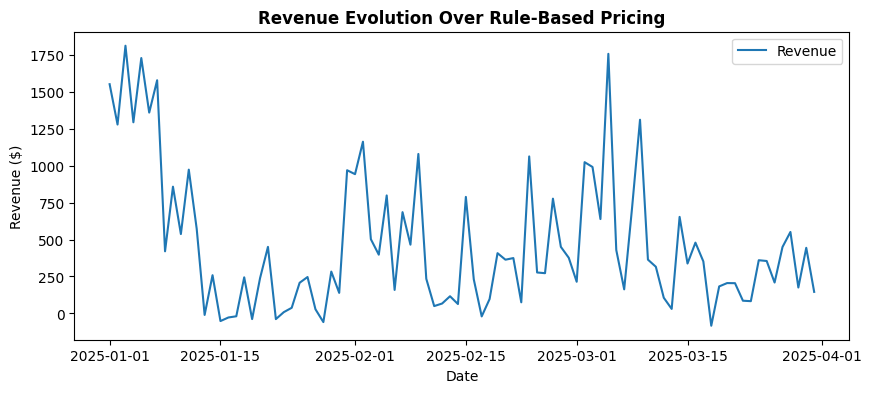

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["revenue"], label="Revenue")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.title("Revenue Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

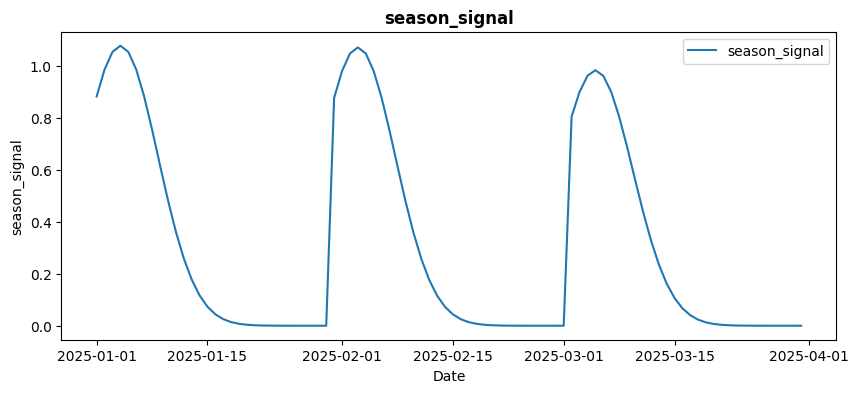

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["season_signal"], label="season_signal")


plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("season_signal")
plt.title("season_signal", fontweight="bold")
plt.show()

In [14]:
df_first_qt.to_csv("data/phase_0.csv", index=False)

### Q1 Data Analysis

---

#### 1. Prices Behavior (Agent vs Competitor)

##### Observations
- Both agent and competitor prices exhibit high volatility throughout the period.
- There is no clear time trend in either series; prices fluctuate across the full range repeatedly.
- The agent explores aggressively, covering a wide portion of the admissible price space.
- The competitor also adjusts prices dynamically, but with slightly more structure and occasional clustering.
- The price gap is not persistent:
  - Periods of higher agent pricing alternate with periods where the competitor is more expensive
  - No sustained dominance of one side

##### Economic Interpretation
- The market operates under a **stationary competitive environment**, with no systematic drift in the price benchmark.
- Both players actively adjust prices:
  - The agent follows an exploratory, rule-based policy
  - The competitor reacts to market conditions but retains some inertia
- The absence of a trend suggests:
  - No long-term deflationary or inflationary pressure
  - A stable reference price level around which both players oscillate

**Implication:**  
The environment is suitable for identifying price-response relationships, as price variation is not confounded by time trends.

##### Statistical Implications
- Prices are broadly distributed over time, improving support for estimation.
- Moderate correlation between agent and competitor prices reflects interaction without collinearity.
- The conditional relationship:
  - $ E[\text{demand} \mid \text{price}] $ is not driven by time trends

**Consequences:**
- Reduced bias in elasticity estimation  
- More stable coefficient estimates  
- Improved identifiability of own- and cross-price effects  

##### RL Impact
- The agent operates in a **stationary learning environment**, which supports convergence.
- Exploration is sufficient to cover the action space.
- The absence of structural drift allows the agent to learn a consistent pricing policy.

---

#### 2. Demand Evolution

##### Observations
- Demand fluctuates over time with intermittent spikes.
- No persistent downward or upward trend is observed.
- Variability remains present throughout the period:
  - Early and later periods both show fluctuations
  - Occasional peaks are aligned with specific periods

##### Economic Interpretation
- Demand is driven by a combination of:
  - Price levels
  - Competitive positioning
  - Seasonal effects
- There is no structural decline in demand:
  - The market remains active across the full horizon
- Demand spikes suggest periods of:
  - Higher willingness to pay
  - Favorable competitive positioning

##### Statistical Implications
- Demand appears **stationary in mean**, with moderate variance.
- No strong evidence of time-driven non-stationarity.
- Correlations indicate (Present at Phase 1):
  - Negative relationship with own price  
  - Positive relationship with relative price  
  - Positive association with seasonal signal  

**Key result:**  
Demand variation is primarily explained by economic drivers rather than time.

##### RL Impact
- The agent can correctly infer price sensitivity.
- Demand signals are informative and consistent across time.
- Learning is not distorted by structural shifts in the environment.

---

#### 3. Revenue Evolution

##### Observations
- Revenue exhibits high variability with frequent spikes.
- No clear trend over time; both high and low revenue periods occur throughout.
- Negative revenue occasionally appears, reflecting cost structure effects.
- Large spikes are associated with:
  - High demand realizations
  - Favorable pricing decisions

##### Economic Interpretation
- Revenue is driven by:
  1. Demand variability  
  2. Price decisions relative to cost  
- The presence of negative values indicates:
  - Pricing below profitable thresholds  
  - Exploration leading to suboptimal decisions  
- High-revenue periods reflect successful alignment of:
  - Price  
  - Demand  
  - Competitive conditions  

##### Statistical Implications
- Revenue distribution is skewed with heavy tails.
- Strong nonlinearity in:
  - Price -> revenue relationship  
- Interaction effects are relevant:
  - Price x demand  
  - Price x competitive position  

##### RL Impact
- Reward signal is informative but noisy.
- Exploration leads to both gains and losses, which is desirable for learning.
- The agent is exposed to a wide range of outcomes, improving policy learning.

---

#### 4. Seasonality Signal

##### Observations
- The seasonal signal follows a smooth, cyclical pattern.
- Peaks are sharp and followed by gradual decay.
- The pattern repeats consistently over time.

##### Economic Interpretation
- Represents cyclical demand drivers such as:
  - Payday effects  
  - Periodic consumption behavior  
- Seasonal peaks correspond to higher demand periods.

##### Statistical Implications
- It contributes to demand variation alongside price and competition.
- Its effect is not dominated by time trends, making it identifiable.

##### RL Impact
- The agent can learn to condition pricing on seasonal signals.
- Seasonal structure provides an opportunity for:
  - State-dependent pricing  
  - Improved policy performance  

---

#### Core Insight from Phase 0

The simulation provides a **well-structured and identifiable environment**.

Demand is driven by:
1. Own price (primary driver)  
2. Relative price vs competitor  
3. Seasonality  
4. Stochastic shocks  

There is no dominant time trend distorting these relationships.

---

#### Evaluation of Phase 0

##### Strengths
- Stationary environment suitable for learning  
- Strong price signal with identifiable elasticity  
- Balanced competition dynamics  
- Meaningful seasonal variation  
- Rich exploration of the price space  

##### Limitations
- Revenue remains highly volatile due to exploration  
- Occasional negative profits from aggressive pricing  
- Requires sufficient data for stable estimation  

---

This setup provides a solid foundation for moving into structural modeling and policy optimization in subsequent phases.